In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os



In [2]:
# data_path = Path(__file__).parent / "openmeteo_data.csv"
# data_path = Path(os.getcwd()) / "openmeteo_data.csv"

data = np.load(Path(os.getcwd()) / "hybrid_gen_data.npz")

wind_gen = data["wind"]
solar_gen = data["solar"]
hybrid_gen = data["hybrid"]

df_gen = pd.DataFrame(dict(wind=wind_gen, solar=solar_gen, hybrid=hybrid_gen))
date_range = pd.date_range(start="1995-01-01 00:00", end="2024-12-31 23:59", freq="h")
df_gen.index = date_range[~((date_range.month == 2) & (date_range.day == 29))]

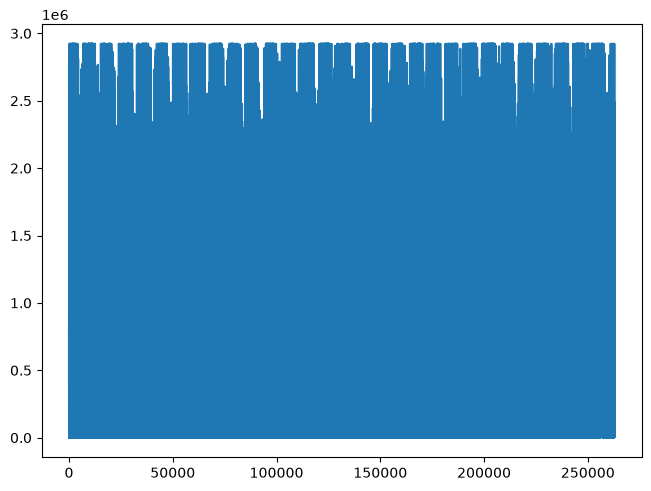

In [3]:
fig, ax = plt.subplots(1, 1, layout="constrained")

ax.plot(df_gen["hybrid"].to_numpy())


interactive(children=(IntSlider(value=1, description='window', max=5000, min=1), Output()), _dom_classes=('wid…

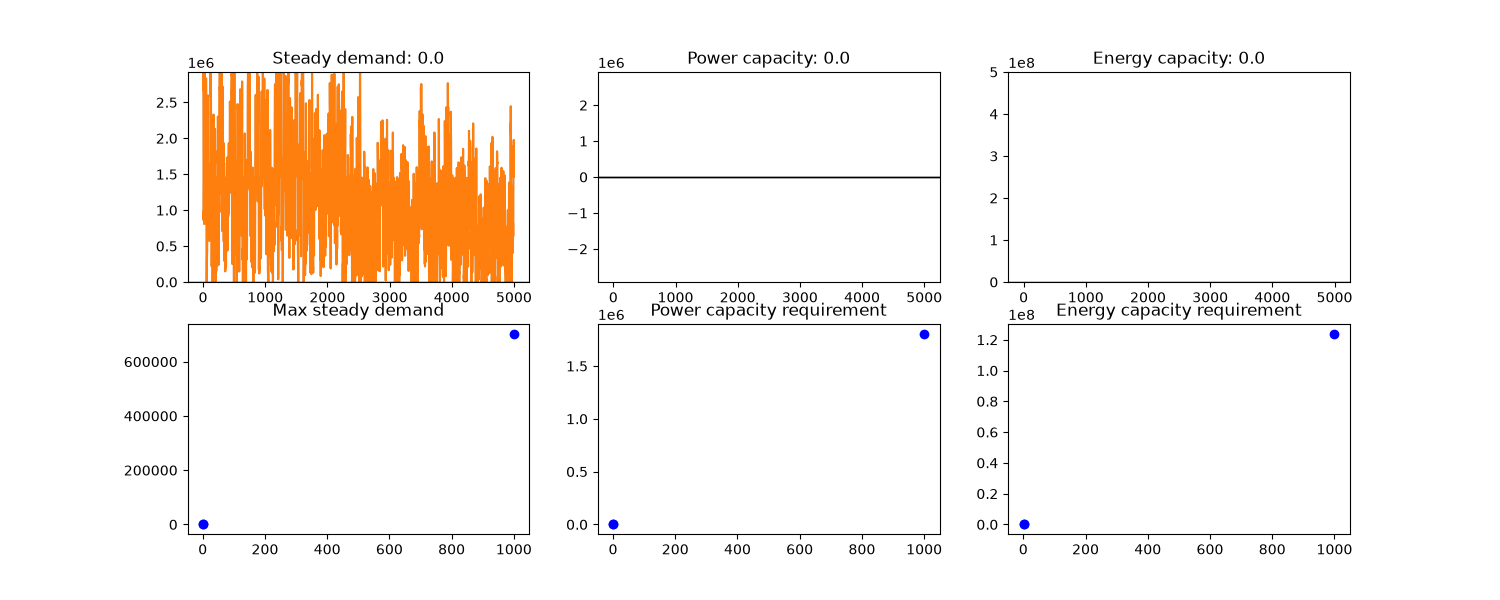

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interact

%matplotlib inline
%matplotlib widget

series = df_gen["hybrid"].to_numpy()[:1000]

x_full = np.arange(len(series))


fig, ax = plt.subplots(2, 3, figsize=(15, 6))
# line, = ax.plot(x_full, series, lw=1.2)
# ax.set_title("Hybrid generation")
# ax.set_xlabel("Hour")
# ax.set_ylabel("Power")
# ax.grid(True)


def calc_battery(generation, demand):
    discharge = demand - generation
    SOC = np.cumsum(discharge)
    SOC = SOC - np.min(SOC)
    return discharge, SOC





def update_window(window=50):
    window = int(window)
    if window < 1 or len(series) == 0:
        return

    ax[0, 0].clear()


    generation = df_gen["hybrid"][10000:15000].to_numpy()
    demand = df_gen["hybrid"].rolling(window=window, center=True).mean().to_numpy()[10000:15000]

    ax[0, 0].plot(generation, alpha=0.25)
    ax[0, 0].plot(demand)


    ax[0, 0].axhline(np.min(demand), color="black", linewidth=1)
    ax[0, 0].set_ylim([0, np.max(df_gen["hybrid"])])
    ax[0, 0].set_title(f"Steady demand: {np.min(demand):.1f}")


    discharge, SOC = calc_battery(generation, demand)

    ax[0, 1].clear()
    ax[0, 1].fill_between(np.arange(len(discharge)), np.zeros(len(discharge)), discharge)
    ax[0, 1].set_ylim([-np.max(df_gen["hybrid"]), np.max(df_gen["hybrid"])])

    power_capacity = max(np.max(discharge), -np.min(discharge))
    ax[0, 1].set_title(f"Power capacity: {power_capacity:.1f}")

    ax[0, 1].axhline(np.max(np.abs(discharge)), color="black", linewidth=1)
    ax[0, 1].axhline(-np.max(np.abs(discharge)), color="black", linewidth=1)


    ax[0, 2].clear()
    ax[0, 2].fill_between(np.arange(len(SOC)), np.zeros(len(SOC)), SOC)
    ax[0, 2].set_ylim([0, 5e8])

    energy_capacity = np.max(SOC)
    ax[0, 2].set_title(f"Energy capacity: {energy_capacity:.1f}")
    ax[0, 2].axhline(np.max(np.abs(SOC)), color="black", linewidth=1)


    
    ax[1, 0].scatter(window, np.min(demand), color="blue")
    ax[1, 0].set_title("Max steady demand")

    ax[1, 1].scatter(window, np.max(np.abs(discharge)), color="blue")
    ax[1, 1].set_title("Power capacity requirement")

    ax[1, 2].scatter(window, energy_capacity, color="blue")
    ax[1, 2].set_title("Energy capacity requirement")
    fig.canvas.draw_idle()


interact(
    update_window,
    window=IntSlider(min=1, max=5000, step=1, value=1),
)

update_window(1000)
update_window(1)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interact

%matplotlib inline
%matplotlib widget

# series = df_gen["hybrid"].to_numpy()[:1000]

# x_full = np.arange(len(series))

fig, ax = plt.subplots(2, 3, figsize=(15, 6))


def calc_battery(generation, demand):
    discharge = demand - generation
    SOC = np.cumsum(discharge)
    SOC = SOC - np.min(SOC)
    return discharge, SOC

def update_window(window=50):
    window = int(window)
    if window < 1 or len(series) == 0:
        return

    ax[0, 0].clear()


    generation = df_gen["hybrid"][10000:15000].to_numpy()
    demand = df_gen["hybrid"].rolling(window=window, center=True).mean().to_numpy()[10000:15000]

    ax[0, 0].plot(generation, alpha=0.25)
    ax[0, 0].plot(demand)


    ax[0, 0].axhline(np.min(demand), color="black", linewidth=1)
    ax[0, 0].set_ylim([0, np.max(df_gen["hybrid"])])
    ax[0, 0].set_title(f"Steady demand: {np.min(demand):.1f}")


    discharge, SOC = calc_battery(generation, demand)

    ax[0, 1].clear()
    ax[0, 1].fill_between(np.arange(len(discharge)), np.zeros(len(discharge)), discharge)
    ax[0, 1].set_ylim([-np.max(df_gen["hybrid"]), np.max(df_gen["hybrid"])])

    power_capacity = max(np.max(discharge), -np.min(discharge))
    ax[0, 1].set_title(f"Power capacity: {power_capacity:.1f}")

    ax[0, 1].axhline(np.max(np.abs(discharge)), color="black", linewidth=1)
    ax[0, 1].axhline(-np.max(np.abs(discharge)), color="black", linewidth=1)


    ax[0, 2].clear()
    ax[0, 2].fill_between(np.arange(len(SOC)), np.zeros(len(SOC)), SOC)
    ax[0, 2].set_ylim([0, 5e8])

    energy_capacity = np.max(SOC)
    ax[0, 2].set_title(f"Energy capacity: {energy_capacity:.1f}")
    ax[0, 2].axhline(np.max(np.abs(SOC)), color="black", linewidth=1)


    
    ax[1, 0].scatter(window, np.min(demand), color="blue")
    ax[1, 0].set_title("Max steady demand")

    ax[1, 1].scatter(window, np.max(np.abs(discharge)), color="blue")
    ax[1, 1].set_title("Power capacity requirement")

    ax[1, 2].scatter(window, energy_capacity, color="blue")
    ax[1, 2].set_title("Energy capacity requirement")
    fig.canvas.draw_idle()


interact(
    update_window,
    window=IntSlider(min=1, max=5000, step=1, value=1),
)

update_window(1000)
update_window(1)

